## ÉTAPE 1 — VISUALISATION DES DONNÉES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Charger les données
df = pd.read_csv("../data/Wind_turbine_data.csv")

# Nettoyage
df = df.drop(columns=["Theoretical_Power_Curve (KWh)"], errors="ignore")

# Renommer
df = df.rename(columns={
    "Date/Time": "Date",
    "LV ActivePower (kW)": "Puissance (kW)",
    "Wind Speed (m/s)": "Vitesse (m/s)",
    "Wind Direction (°)": "Direction (°)"
})

# Date
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.set_index("Date")

df.head()

,Puissance (kW),Vitesse (m/s),Direction (°)
Date,,,
2018-01-01 00:00:00,380.047791,5.311336,259.994904
2018-01-01 00:10:00,453.769196,5.672167,268.641113
2018-01-01 00:20:00,306.376587,5.216037,272.564789
2018-01-01 00:30:00,419.645905,5.659674,271.258087
2018-01-01 00:40:00,380.650696,5.577941,265.674286


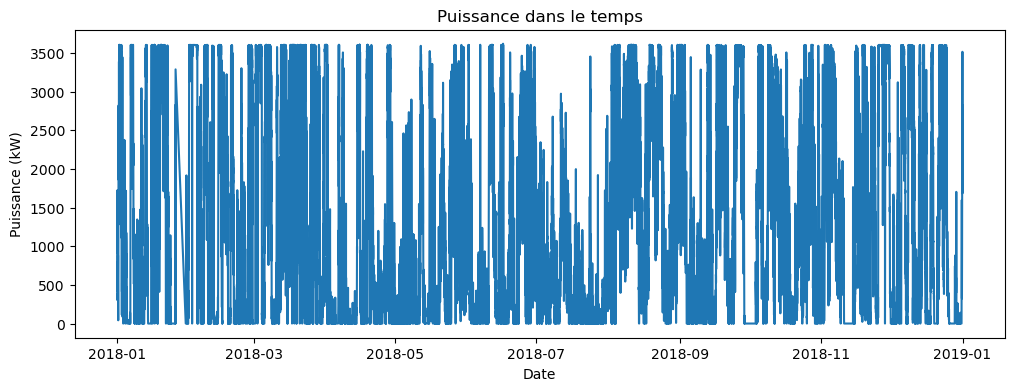

In [3]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df["Puissance (kW)"])
plt.title("Puissance dans le temps")
plt.xlabel("Date")
plt.ylabel("Puissance (kW)")
plt.show()

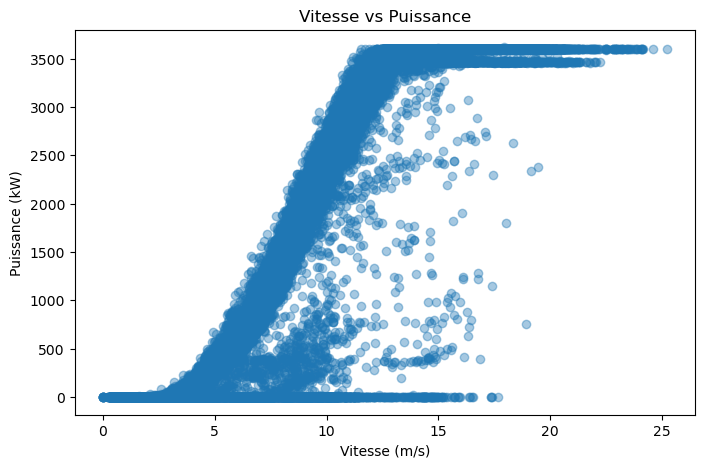

In [4]:
plt.figure(figsize=(8,5))
plt.scatter(df["Vitesse (m/s)"], df["Puissance (kW)"], alpha=0.4)
plt.title("Vitesse vs Puissance")
plt.xlabel("Vitesse (m/s)")
plt.ylabel("Puissance (kW)")
plt.show()

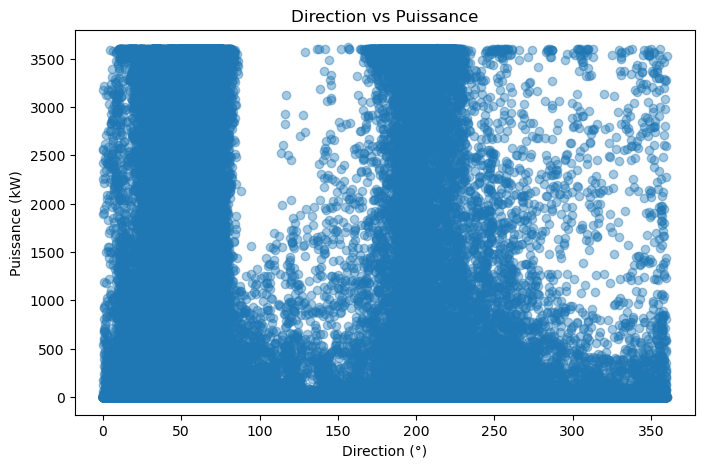

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(df["Direction (°)"], df["Puissance (kW)"], alpha=0.4)
plt.title("Direction vs Puissance")
plt.xlabel("Direction (°)")
plt.ylabel("Puissance (kW)")
plt.show()

## Interprétation

- La puissance augmente avec la vitesse du vent
- La relation vitesse → puissance est forte
- La direction a moins d’impact
- Données adaptées à une régression

## ÉTAPE 2 — PRÉPARATION DES DONNÉES

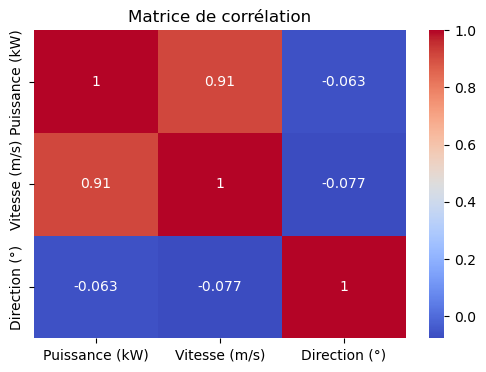

In [6]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

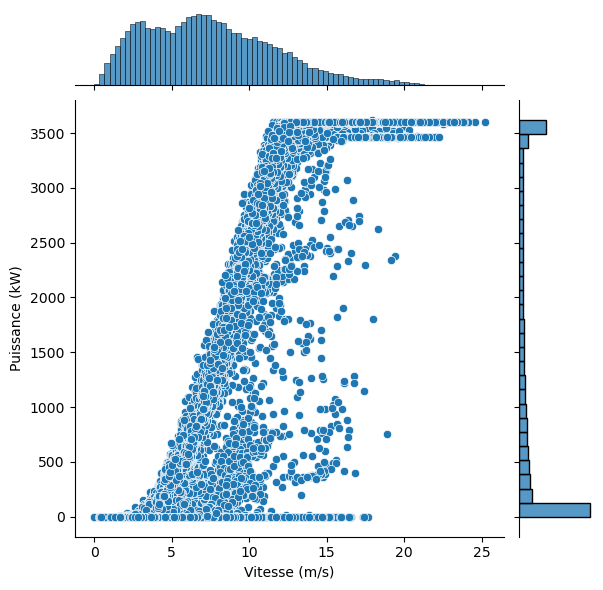

In [7]:
sns.jointplot(x=df["Vitesse (m/s)"], y=df["Puissance (kW)"])
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import numpy as np

# Filtrer
df_clean = df[df["Puissance (kW)"] > 0]

# Variables
X = np.array(df_clean["Vitesse (m/s)"]).reshape(-1,1)
y = np.array(df_clean["Puissance (kW)"]).reshape(-1,1)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler_X = RobustScaler()
scaler_y = RobustScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

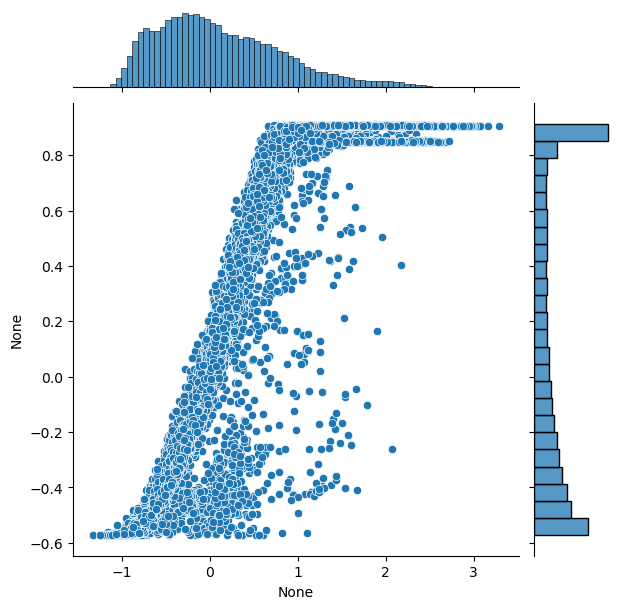

In [9]:
sns.jointplot(x=X_train.flatten(), y=y_train.flatten())
plt.show()

## Interprétation

- La vitesse reste la variable principale
- Le scaling rend les données plus stables
- Les données sont prêtes pour un modèle de régression

## ÉTAPE 3 — MODÉLISATION

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Filtrage
df = df[df["Puissance (kW)"] > 0.01]
df = df[(df["Vitesse (m/s)"] > 0.1) & (df["Vitesse (m/s)"] < 25.5)]

# Variables
x = np.array(df["Vitesse (m/s)"]).reshape(-1, 1)
y = np.array(df["Puissance (kW)"])

# Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=22
)

# Scaling
scaler = RobustScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, ElasticNet

# Création des features polynomiales
poly = PolynomialFeatures(degree=12, include_bias=False)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# Modèles
model1 = Lasso(max_iter=10000, alpha=1e-3)
model2 = ElasticNet(max_iter=10000, alpha=1e-3, l1_ratio=0.5)

# Entraînement
model1.fit(x_train_poly, y_train)
model2.fit(x_train_poly, y_train)

# Prédictions
y_pred1 = model1.predict(x_test_poly)
y_pred2 = model2.predict(x_test_poly)

c:\Users\jayja\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.116e+09, tolerance: 5.067e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\jayja\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.182e+09, tolerance: 5.067e+06
  model = cd_fast.enet_coordinate_descent(


In [12]:
print("R² Lasso :", model1.score(x_test_poly, y_test))
print("R² ElasticNet :", model2.score(x_test_poly, y_test))

R² Lasso : 0.9556245790174701
R² ElasticNet : 0.9555733090546946


## Interprétation

Les deux modèles permettent de prédire la puissance à partir de la vitesse du vent.

Le score R² indique la qualité du modèle. Plus il est proche de 1, meilleure est la prédiction.

On peut comparer les performances entre Lasso et ElasticNet pour choisir le meilleur modèle.

In [13]:
# Création d'une grille de valeurs
x_grid = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)

# Scaling
x_grid_scaled = scaler.transform(x_grid)

# Transformation polynomiale
x_grid_poly = poly.transform(x_grid_scaled)

# Prédictions
y_grid1 = model1.predict(x_grid_poly)
y_grid2 = model2.predict(x_grid_poly)

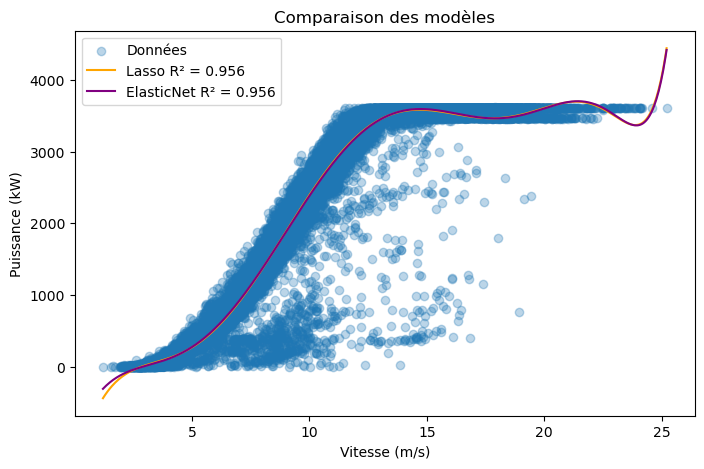

In [14]:
plt.figure(figsize=(8,5))

# Données réelles
plt.scatter(x, y, alpha=0.3, label="Données")

# Courbes des modèles
plt.plot(x_grid, y_grid1, color="orange",
         label=f"Lasso R² = {model1.score(x_test_poly, y_test):.3f}")

plt.plot(x_grid, y_grid2, color="purple",
         label=f"ElasticNet R² = {model2.score(x_test_poly, y_test):.3f}")

plt.xlabel("Vitesse (m/s)")
plt.ylabel("Puissance (kW)")
plt.legend()
plt.title("Comparaison des modèles")

plt.show()

## Interprétation finale

Les modèles Lasso et ElasticNet permettent de prédire la puissance produite par l’éolienne en fonction de la vitesse du vent.

Les courbes montrent que la relation n’est pas linéaire, ce qui justifie l’utilisation de features polynomiales.

Le score R² permet de comparer les performances. Le modèle ayant le score le plus élevé est le plus précis.

Globalement, les modèles capturent bien la tendance des données.

## ÉTAPE 4 — OPTIMISATION AVEC CROSS-VALIDATION

In [15]:
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV

t_start = time.time()

In [16]:
pipe_lasso = Pipeline([
    ("scaler", RobustScaler()),
    ("poly", PolynomialFeatures(degree=12, include_bias=False)),
    ("model", Lasso(max_iter=100000))
])

params_lasso = {
    "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

lasso_grid = GridSearchCV(
    estimator=pipe_lasso,
    param_grid=params_lasso,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(x_train, y_train)

print("Meilleur score Lasso :", lasso_grid.best_score_)
print("Meilleurs paramètres Lasso :", lasso_grid.best_params_)

lasso_opt = lasso_grid.best_estimator_

Meilleur score Lasso : 0.9560917723182503
Meilleurs paramètres Lasso : {'model__alpha': 1e-05}


c:\Users\jayja\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.110e+09, tolerance: 5.067e+06
  model = cd_fast.enet_coordinate_descent(


In [17]:
pipe_elastic = Pipeline([
    ("scaler", RobustScaler()),
    ("poly", PolynomialFeatures(degree=12, include_bias=False)),
    ("model", ElasticNet(max_iter=100000))
])

params_elastic = {
    "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    "model__l1_ratio": [0.05, 0.1, 0.5, 0.9, 1.0]
}

elastic_grid = GridSearchCV(
    estimator=pipe_elastic,
    param_grid=params_elastic,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

elastic_grid.fit(x_train, y_train)

print("Meilleur score ElasticNet :", elastic_grid.best_score_)
print("Meilleurs paramètres ElasticNet :", elastic_grid.best_params_)

elastic_opt = elastic_grid.best_estimator_

Meilleur score ElasticNet : 0.9560996298518519
Meilleurs paramètres ElasticNet : {'model__alpha': 0.0001, 'model__l1_ratio': 0.1}


c:\Users\jayja\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.123e+09, tolerance: 5.067e+06
  model = cd_fast.enet_coordinate_descent(


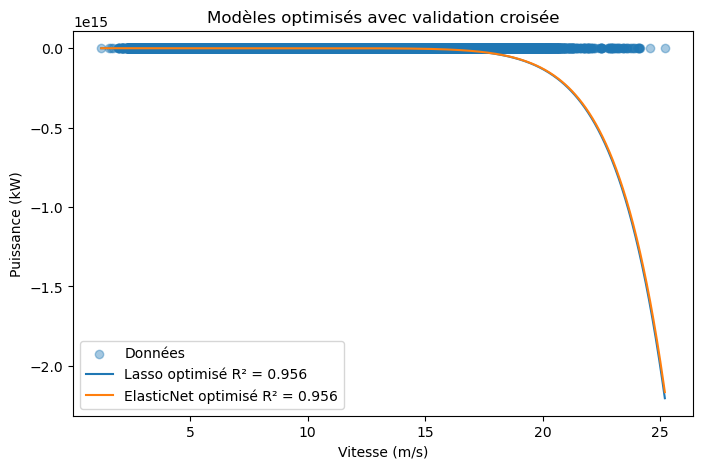

Temps de calcul total = 5252.14 s


In [18]:
x_grid = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)

y_lasso = lasso_opt.predict(x_grid)
y_elastic = elastic_opt.predict(x_grid)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Données", alpha=0.4)

plt.plot(
    x_grid,
    y_lasso,
    label=f"Lasso optimisé R² = {lasso_opt.score(x_test, y_test):.3f}"
)

plt.plot(
    x_grid,
    y_elastic,
    label=f"ElasticNet optimisé R² = {elastic_opt.score(x_test, y_test):.3f}"
)

plt.xlabel("Vitesse (m/s)")
plt.ylabel("Puissance (kW)")
plt.legend()
plt.title("Modèles optimisés avec validation croisée")
plt.show()

elapsed_time = time.time() - t_start
print(f"Temps de calcul total = {elapsed_time:.2f} s")

## Interprétation

La validation croisée permet de tester plusieurs valeurs d’hyperparamètres et de choisir celles qui donnent le meilleur score moyen.

Pour Lasso, le meilleur paramètre est alpha. Pour ElasticNet, les meilleurs paramètres sont alpha et l1_ratio.

Le score best_score_ correspond au score moyen obtenu pendant la validation croisée. Le score affiché sur le graphique correspond au score R² obtenu sur le jeu de test.

L’utilisation d’un Pipeline permet d’éviter la fuite d’information, car le scaler et les features polynomiales sont appliqués correctement pendant la validation croisée.

## ÉTAPE 5 — UTILISATION DES PIPELINES

In [19]:
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.pipeline import make_pipeline

t_start = time.time()

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

In [20]:
lasso_pipeline = make_pipeline(
    PolynomialFeatures(),
    RobustScaler(),
    Lasso()
)

lasso_params = {
    "polynomialfeatures__degree": [4, 6, 8, 10, 12, 14, 16, 18, 20],
    "polynomialfeatures__include_bias": [False],
    "lasso__max_iter": [50000],
    "lasso__alpha": [1e-4, 1e-3, 1e-2, 1e-1]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid=lasso_params,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(x_train, y_train)

best_comb_lasso = {
    "R2": lasso_grid.best_score_,
    "Params": lasso_grid.best_params_
}

lasso_opt = lasso_grid.best_estimator_
y_pred_lasso = lasso_opt.predict(x_test)

best_comb_lasso

c:\Users\jayja\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.188e+09, tolerance: 5.069e+06
  model = cd_fast.enet_coordinate_descent(


{'R2': np.float64(0.9544429690210798),
 'Params': {'lasso__alpha': 0.1,
  'lasso__max_iter': 50000,
  'polynomialfeatures__degree': 16,
  'polynomialfeatures__include_bias': False}}

In [21]:
elastic_pipeline = make_pipeline(
    PolynomialFeatures(),
    RobustScaler(),
    ElasticNet()
)

elastic_params = {
    "polynomialfeatures__degree": [4, 6, 8, 10, 12, 14, 16, 18, 20],
    "polynomialfeatures__include_bias": [False],
    "elasticnet__max_iter": [50000],
    "elasticnet__alpha": [1e-4, 1e-3, 1e-2, 1e-1],
    "elasticnet__l1_ratio": [0.01, 0.1, 0.5, 1.0]
}

elastic_grid = GridSearchCV(
    elastic_pipeline,
    param_grid=elastic_params,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

elastic_grid.fit(x_train, y_train)

best_comb_elastic = {
    "R2": elastic_grid.best_score_,
    "Params": elastic_grid.best_params_
}

elastic_opt = elastic_grid.best_estimator_
y_pred_elastic = elastic_opt.predict(x_test)

best_comb_elastic

c:\Users\jayja\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.182e+09, tolerance: 5.069e+06
  model = cd_fast.enet_coordinate_descent(


{'R2': np.float64(0.9545227627284347),
 'Params': {'elasticnet__alpha': 0.0001,
  'elasticnet__l1_ratio': 0.5,
  'elasticnet__max_iter': 50000,
  'polynomialfeatures__degree': 16,
  'polynomialfeatures__include_bias': False}}

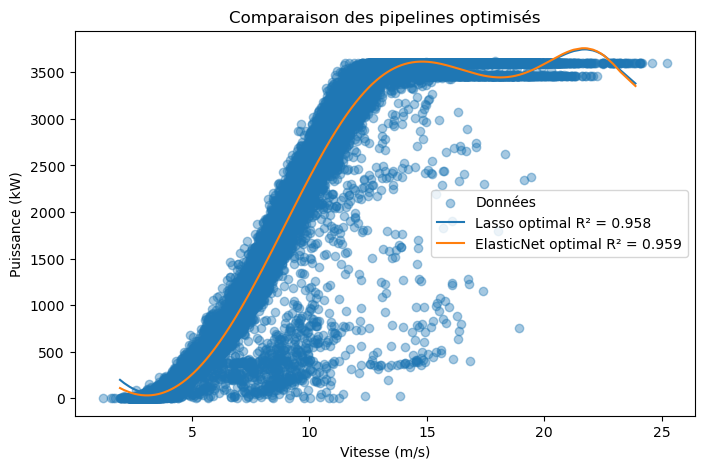

Temps de calcul total = 7715.09 s


In [22]:
predictions = np.column_stack((x_test.ravel(), y_pred_lasso, y_pred_elastic))
predictions = predictions[np.argsort(predictions[:, 0])]

plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Données", alpha=0.4)

plt.plot(
    predictions[:, 0],
    predictions[:, 1],
    label=f"Lasso optimal R² = {lasso_opt.score(x_test, y_test):.3f}"
)

plt.plot(
    predictions[:, 0],
    predictions[:, 2],
    label=f"ElasticNet optimal R² = {elastic_opt.score(x_test, y_test):.3f}"
)

plt.xlabel("Vitesse (m/s)")
plt.ylabel("Puissance (kW)")
plt.legend()
plt.title("Comparaison des pipelines optimisés")
plt.show()

elapsed_time = time.time() - t_start
print(f"Temps de calcul total = {elapsed_time:.2f} s")

## Interprétation

Cette étape utilise des pipelines pour regrouper les transformations et le modèle dans une seule structure.

Les pipelines permettent d’appliquer correctement PolynomialFeatures, RobustScaler et le modèle pendant la validation croisée.

GridSearchCV teste plusieurs combinaisons d’hyperparamètres et conserve le meilleur modèle.

Les résultats permettent de comparer Lasso et ElasticNet avec leurs meilleurs paramètres.

## ÉTAPE 6 — SÉLECTION FINALE DE LA MEILLEURE MÉTHODE

In [23]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

svr_pipeline = make_pipeline(
    RobustScaler(),
    SVR()
)

svr_params = {
    "svr__C": [0.1, 1, 2, 5, 10],
    "svr__epsilon": [0.01, 0.1, 0.2, 0.5, 1]
}

svr_grid = GridSearchCV(
    svr_pipeline,
    param_grid=svr_params,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

svr_grid.fit(x_train, y_train)

svr_opt = svr_grid.best_estimator_
y_pred_svr = svr_opt.predict(x_test)

print("Meilleur score SVR :", svr_grid.best_score_)
print("Meilleurs paramètres SVR :", svr_grid.best_params_)

Meilleur score SVR : 0.9544402980719544
Meilleurs paramètres SVR : {'svr__C': 10, 'svr__epsilon': 0.1}


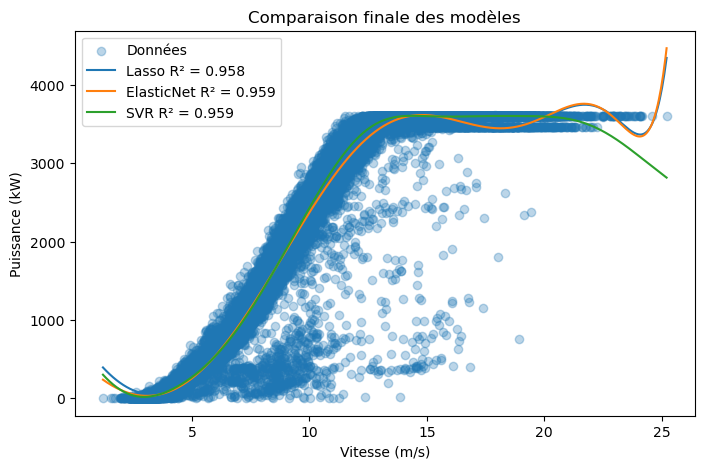

In [24]:
x_grid = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)

y_grid_lasso = lasso_opt.predict(x_grid)
y_grid_elastic = elastic_opt.predict(x_grid)
y_grid_svr = svr_opt.predict(x_grid)

plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Données", alpha=0.3)

plt.plot(x_grid, y_grid_lasso,
         label=f"Lasso R² = {lasso_opt.score(x_test, y_test):.3f}")

plt.plot(x_grid, y_grid_elastic,
         label=f"ElasticNet R² = {elastic_opt.score(x_test, y_test):.3f}")

plt.plot(x_grid, y_grid_svr,
         label=f"SVR R² = {svr_opt.score(x_test, y_test):.3f}")

plt.xlabel("Vitesse (m/s)")
plt.ylabel("Puissance (kW)")
plt.legend()
plt.title("Comparaison finale des modèles")

plt.show()

## Interprétation finale

Cette étape permet de comparer 3 modèles : Lasso, ElasticNet et SVR.

Les scores R² permettent d’évaluer la qualité des modèles sur le jeu de test.

La visualisation montre que certains modèles suivent mieux la forme non linéaire des données.

Le modèle SVR est souvent plus flexible et peut mieux capturer la relation entre la vitesse du vent et la puissance produite.

Le choix final du modèle dépend à la fois du score et de la qualité visuelle des prédictions.

## ÉTAPE 7 — PRÉDICTION FINALE DE LA PRODUCTION ÉNERGETIQUE D'UN CHAMP D'ÉOLIENNES

In [25]:
df_wind = pd.read_csv("../data/Wind_speed_data.csv", sep=";")

df_wind = df_wind.drop(columns=["orientation"], errors="ignore")

df_wind["Date"] = pd.to_datetime(df_wind["Date"], format="%d/%m/%y %H:%M")

df_wind = df_wind[
    (df_wind["Date"].dt.month == 4) &
    (df_wind["Date"].dt.year == 2020)
]

df_wind.head()

,Date,wind_speed
468,2020-04-01 00:00:00,9.420
469,2020-04-01 01:00:00,9.105
470,2020-04-01 02:00:00,8.805
471,2020-04-01 03:00:00,8.490
472,2020-04-01 04:00:00,8.220


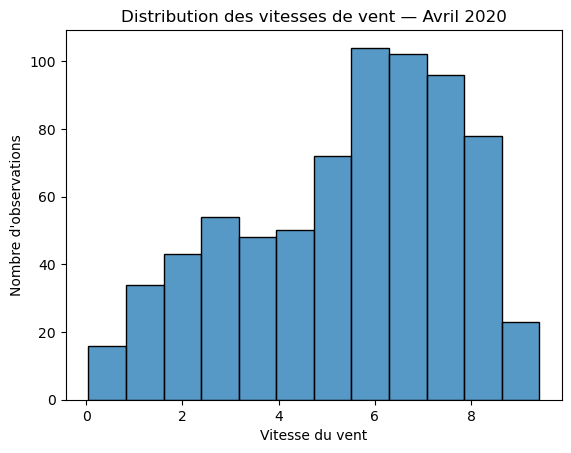

In [26]:
sns.histplot(df_wind["wind_speed"])
plt.title("Distribution des vitesses de vent — Avril 2020")
plt.xlabel("Vitesse du vent")
plt.ylabel("Nombre d'observations")
plt.show()

In [27]:
wind_speeds = df_wind["wind_speed"].to_numpy().reshape(-1, 1)

power_pred = svr_opt.predict(wind_speeds)

energy_hourly_pred = power_pred * 1

total_energy_production = energy_hourly_pred.sum() * 50

print(f"Production totale estimée pour 50 éoliennes = {total_energy_production:.2f} kWh")

Production totale estimée pour 50 éoliennes = 22999956.11 kWh


In [28]:
monthly_conso = 180

nb_personnes = np.floor(total_energy_production / monthly_conso)

print(f"Nombre estimé d'habitants alimentés = {nb_personnes:.0f}")

pourcentage = np.round((nb_personnes / 68000000) * 100, decimals=2)

print(f"Soit environ {pourcentage}% d'une population de référence de 68 millions d'habitants")

Nombre estimé d'habitants alimentés = 127777
Soit environ 0.19% d'une population de référence de 68 millions d'habitants


## Interprétation finale

Dans cette étape, le modèle SVR optimisé est utilisé pour prédire la puissance produite à partir des vitesses de vent du mois d’avril 2020.

Comme chaque observation représente une heure, la puissance prédite en kW peut être convertie en énergie horaire en kWh.

La somme des prédictions permet d’estimer la production mensuelle d’une éolienne. Cette valeur est ensuite multipliée par 50 pour estimer la production totale d’un champ de 50 éoliennes.

Enfin, cette production est comparée à une consommation moyenne mensuelle de 180 kWh par habitant afin d’estimer le nombre de personnes pouvant être alimentées.